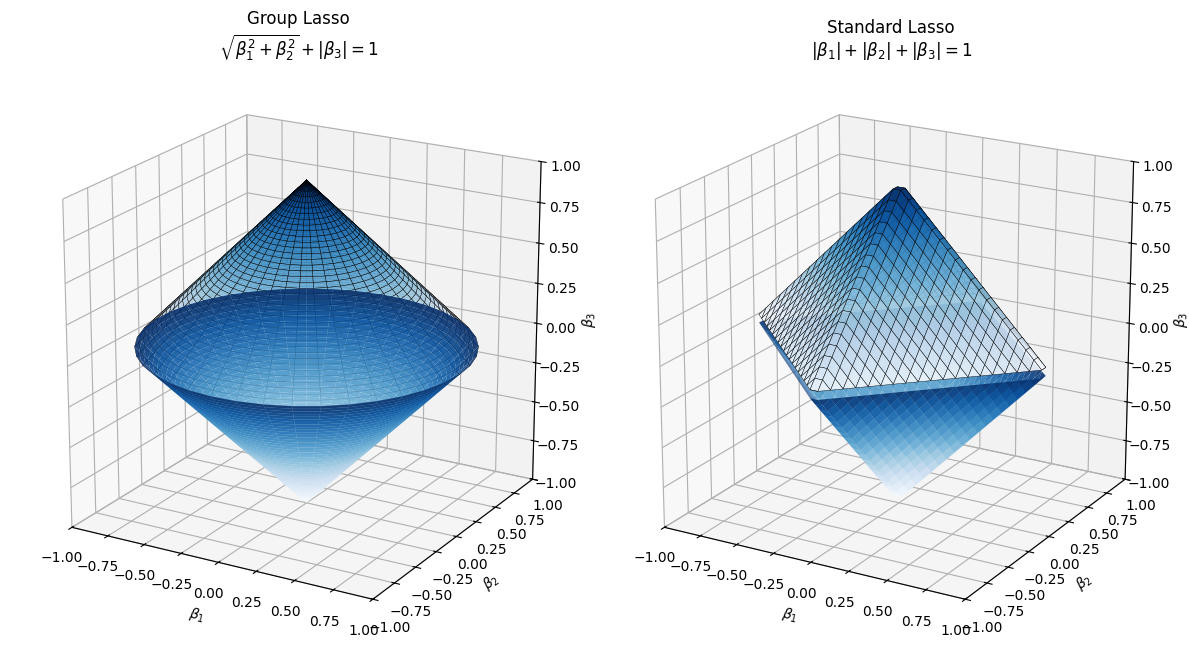

In [26]:
import numpy as np
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 8))
elev, azim = 20, -60

# --- Panel 1: Group Lasso ---
ax1 = fig.add_subplot(121, projection='3d')
r = np.linspace(0, 1, 40)
theta = np.linspace(0, 2 * np.pi, 40)
R, Theta = np.meshgrid(r, theta)

beta1 = R * np.cos(Theta)
beta2 = R * np.sin(Theta)
beta3_top = 1 - R
beta3_bottom = -(1 - R)

# Top surface with black mesh, bottom surface without mesh
ax1.plot_surface(beta1, beta2, beta3_top, cmap='Blues', edgecolor='black', alpha=0.9, linewidth=0.3)
ax1.plot_surface(beta1, beta2, beta3_bottom, cmap='Blues', edgecolor='none', alpha=0.9)

ax1.set_xlim([-1, 1]); ax1.set_ylim([-1, 1]); ax1.set_zlim([-1, 1])
ax1.set_xlabel('$\\beta_1$')
ax1.set_ylabel('$\\beta_2$')
ax1.set_zlabel('$\\beta_3$')
ax1.set_title('Group Lasso\n$\\sqrt{\\beta_1^2+\\beta_2^2} + |\\beta_3| = 1$')
ax1.view_init(elev=elev, azim=azim)
ax1.set_box_aspect([1, 1, 1])

# --- Panel 2: Standard Lasso ---
ax2 = fig.add_subplot(122, projection='3d')
x = np.linspace(-1, 1, 40)
y = np.linspace(-1, 1, 40)
X, Y = np.meshgrid(x, y)

Z_top = 1 - np.abs(X) - np.abs(Y)
Z_top[Z_top < 0] = np.nan

Z_bottom = -(1 - np.abs(X) - np.abs(Y))
Z_bottom[Z_bottom > 0] = np.nan

# Top surface with black mesh, bottom surface without mesh
ax2.plot_surface(X, Y, Z_top, cmap='Blues', edgecolor='black', alpha=0.9, linewidth=0.3)
ax2.plot_surface(X, Y, Z_bottom, cmap='Blues', edgecolor='none', alpha=0.9)

ax2.set_xlim([-1, 1]); ax2.set_ylim([-1, 1]); ax2.set_zlim([-1, 1])
ax2.set_xlabel('$\\beta_1$')
ax2.set_ylabel('$\\beta_2$')
ax2.set_zlabel('$\\beta_3$')
ax2.set_title('Standard Lasso\n$|\\beta_1| + |\\beta_2| + |\\beta_3| = 1$')
ax2.view_init(elev=elev, azim=azim)
ax2.set_box_aspect([1, 1, 1])

plt.tight_layout()
# 기존의 plt.show() 또는 plt.savefig(...)를 이 한 줄로 대체하세요.
plt.savefig('corrected_lasso.pdf', format='pdf', bbox_inches='tight')